# Calcutta Auction Analysis

Explores historical Calcutta auction data joined with tournament outcomes.
Uses `build_calcutta_master.py` to produce the master dataset.

In [16]:
%run build_calcutta_master.py

Rows: 128
Seasons: [2024, 2025]
Stage join rate: 100.0%

Sample row:
season                               2024
team_id                              1314
team_name                  North Carolina
seed                                    1
seed_region                             X
region                               West
conference                            acc
winning_bid                         13500
owner_name          Kent, Kenny + Company
reached_r64                             1
reached_r32                             1
reached_s16                             1
reached_e8                              0
reached_f4                              0
reached_f2                              0
won_championship                        0
furthest_round                          2
payout_pct                          0.015
payout_dollars                     6591.0
roi                               -0.5118

Saved to /Users/harrywang/Desktop/Data Projects/march-madness-calcutta/data/calcutta_maste

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

df = pd.read_csv("../../data/calcutta_master.csv")
df.head()

,season,team_id,team_name,seed,seed_region,region,conference,winning_bid,owner_name,reached_r64,reached_r32,reached_s16,reached_e8,reached_f4,reached_f2,won_championship,furthest_round,payout_pct,payout_dollars,roi
0,2024,1314,North Carolina,1,X,West,acc,13500,"Kent, Kenny + Company",1,1,1,0,0,0,0,2,0.0150,6591.0,-0.5118
1,2024,1345,Purdue,1,Y,Midwest,big_ten,20000,Bisaillon + Hilding + Dudash + Nardi + Carr,1,1,1,1,1,1,0,5,0.1075,47235.5,1.3618
2,2024,1222,Houston,1,Z,South,big_twelve,22000,Moncrief + Sparty,1,1,1,0,0,0,0,2,0.0150,6591.0,-0.7004
3,2024,1163,Connecticut,1,W,East,big_east,31000,"Kent, Kenny + Company",1,1,1,1,1,1,1,6,0.1775,77993.5,1.5159
4,2024,1112,Arizona,2,X,West,pac_twelve,13800,McManama,1,1,1,0,0,0,0,2,0.0150,6591.0,-0.5224


### Auction Price by Seed (Box Plot)
How does the auction pool price each seed line?

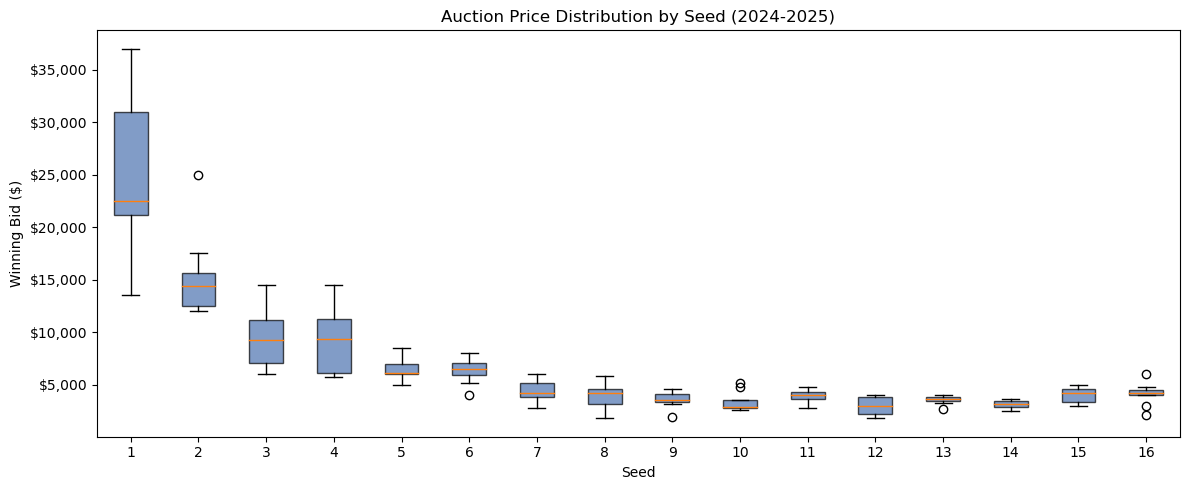

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
seeds_sorted = sorted(df["seed"].unique())
data_by_seed = [df[df["seed"] == s]["winning_bid"] for s in seeds_sorted]
bp = ax.boxplot(data_by_seed, labels=seeds_sorted, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#4C72B0")
    patch.set_alpha(0.7)
ax.set_xlabel("Seed")
ax.set_ylabel("Winning Bid ($)")
ax.set_title("Auction Price Distribution by Seed (2024-2025)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

### Auction Price by Seed (Mean Bar)
Average winning bid per seed.

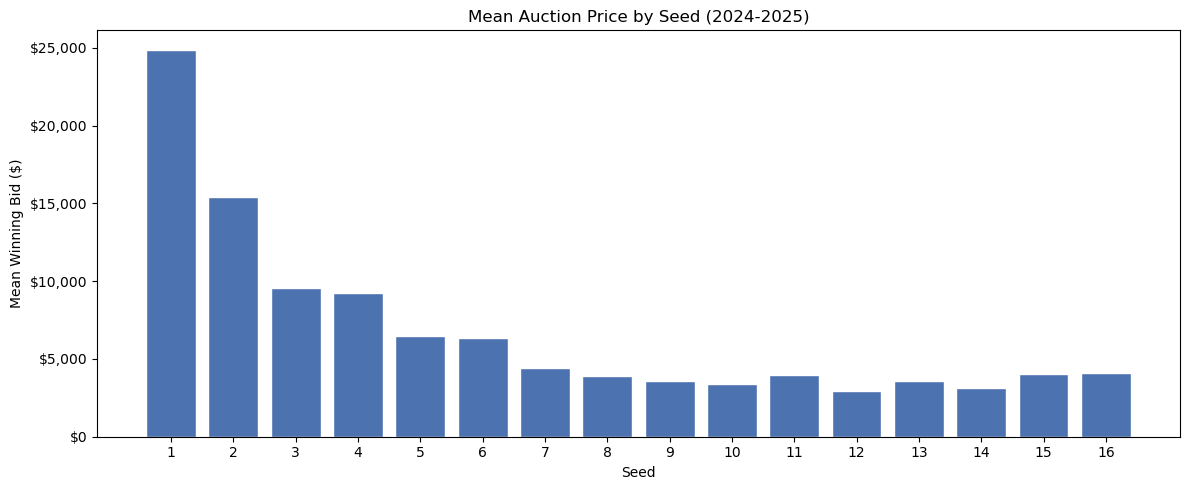

In [19]:
mean_by_seed = df.groupby("seed")["winning_bid"].mean().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(mean_by_seed.index, mean_by_seed.values, color="#4C72B0", edgecolor="white")
ax.set_xlabel("Seed")
ax.set_ylabel("Mean Winning Bid ($)")
ax.set_title("Mean Auction Price by Seed (2024-2025)")
ax.set_xticks(mean_by_seed.index)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

### Auction Price vs Tournament Round Reached
Do expensive teams actually go deeper?

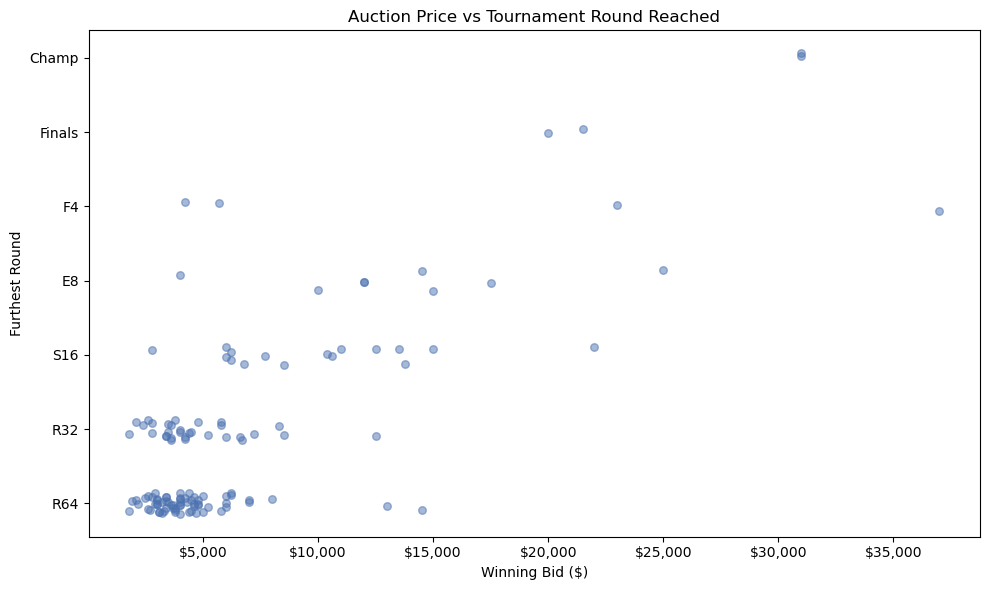

In [20]:
round_labels = {0: "R64", 1: "R32", 2: "S16", 3: "E8", 4: "F4", 5: "Finals", 6: "Champ"}

fig, ax = plt.subplots(figsize=(10, 6))
jitter = np.random.default_rng(42).uniform(-0.15, 0.15, size=len(df))
ax.scatter(df["winning_bid"], df["furthest_round"] + jitter, alpha=0.5, s=30, c="#4C72B0")
ax.set_xlabel("Winning Bid ($)")
ax.set_ylabel("Furthest Round")
ax.set_title("Auction Price vs Tournament Round Reached")
ax.set_yticks(list(round_labels.keys()))
ax.set_yticklabels(list(round_labels.values()))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

### ROI by Seed
Which seeds are overvalued vs undervalued in the auction?

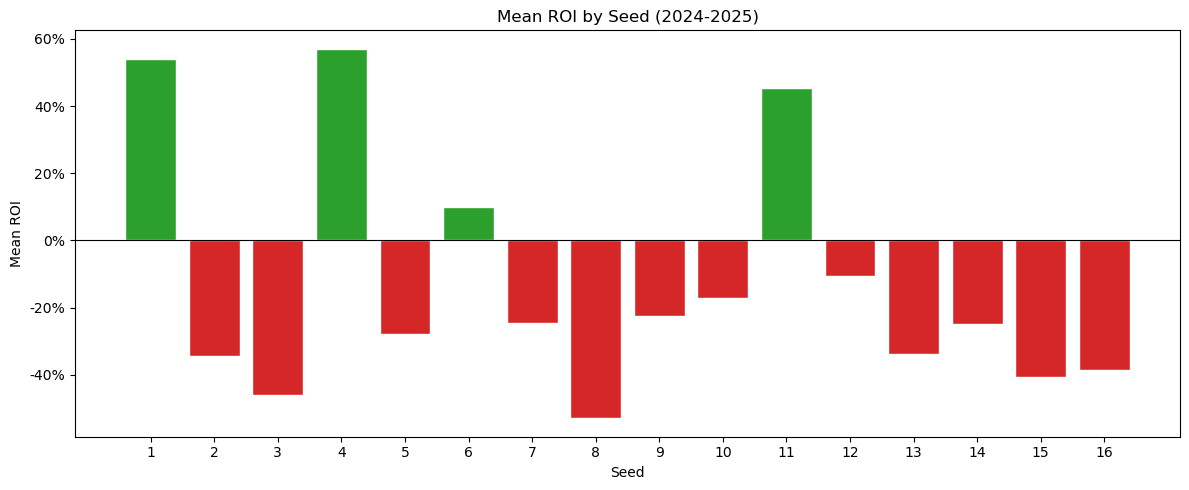

In [21]:
roi_by_seed = df.groupby("seed")["roi"].mean().sort_index()
colors = ["#2ca02c" if v >= 0 else "#d62728" for v in roi_by_seed]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(roi_by_seed.index, roi_by_seed.values, color=colors, edgecolor="white")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Seed")
ax.set_ylabel("Mean ROI")
ax.set_title("Mean ROI by Seed (2024-2025)")
ax.set_xticks(roi_by_seed.index)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout()
plt.show()

### Owner Spend & Payout Summary (2024)
Total spend vs total payout per owner. 2025 excluded (owners are UNKNOWN).

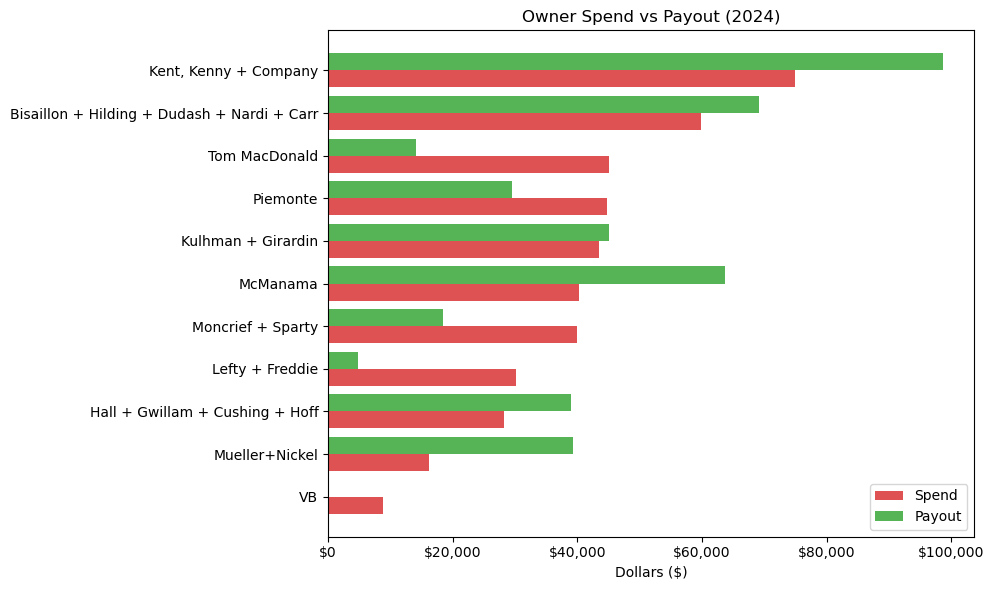

In [22]:
df_2024 = df[df["season"] == 2024].copy()
owner_summary = df_2024.groupby("owner_name").agg(
    total_spend=("winning_bid", "sum"),
    total_payout=("payout_dollars", "sum"),
).sort_values("total_spend", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = range(len(owner_summary))
ax.barh(y_pos, owner_summary["total_spend"], height=0.4, label="Spend", color="#d62728", alpha=0.8)
ax.barh([y + 0.4 for y in y_pos], owner_summary["total_payout"], height=0.4, label="Payout", color="#2ca02c", alpha=0.8)
ax.set_yticks([y + 0.2 for y in y_pos])
ax.set_yticklabels(owner_summary.index)
ax.set_xlabel("Dollars ($)")
ax.set_title("Owner Spend vs Payout (2024)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()

### Price vs Payout with Break-Even Line
Points above the diagonal were profitable purchases.

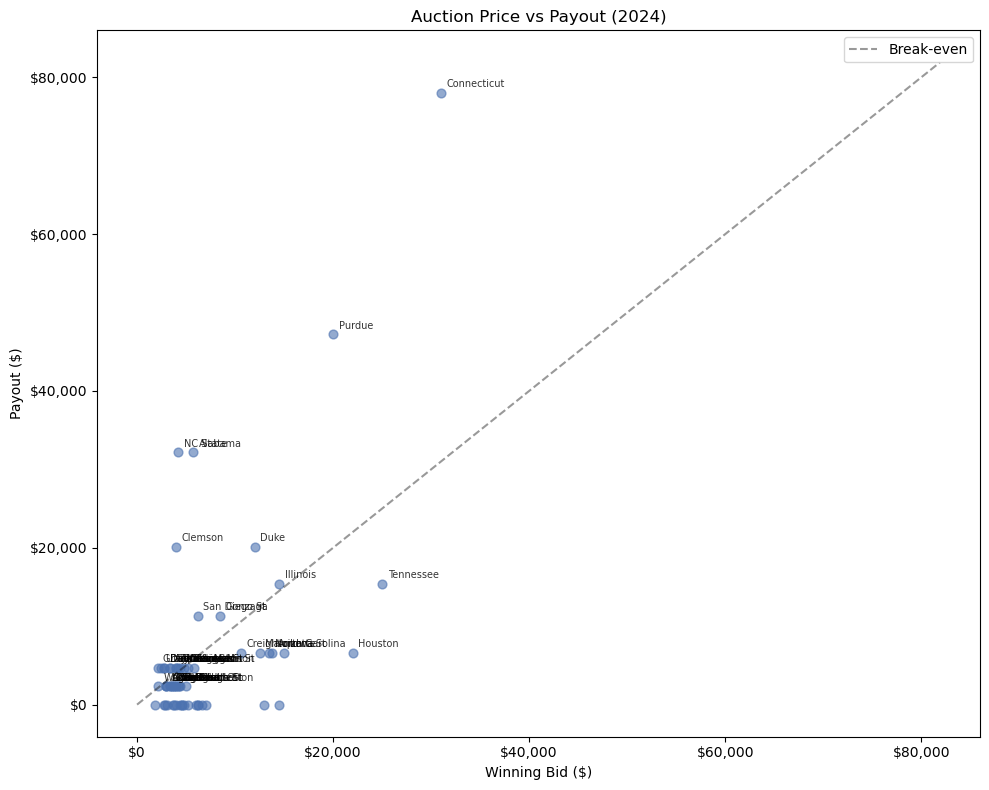

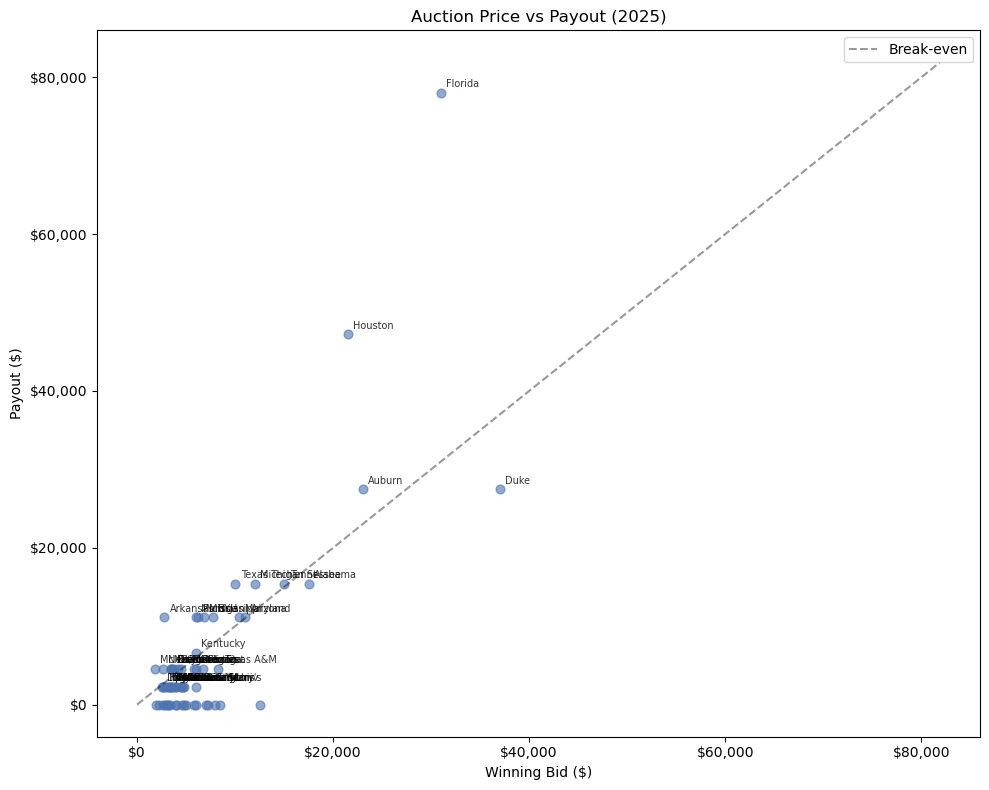

In [24]:
for year in sorted(df["season"].unique()):
    df_year = df[df["season"] == year]

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(df_year["winning_bid"], df_year["payout_dollars"], alpha=0.6, s=40, c="#4C72B0")

    # Label teams with non-zero payout
    for _, row in df_year[df_year["payout_dollars"] > 0].iterrows():
        ax.annotate(row["team_name"], (row["winning_bid"], row["payout_dollars"]),
                    fontsize=7, alpha=0.8, xytext=(4, 4), textcoords="offset points")

    # Break-even line
    max_val = max(df_year["winning_bid"].max(), df_year["payout_dollars"].max()) * 1.05
    ax.plot([0, max_val], [0, max_val], "k--", alpha=0.4, label="Break-even")
    ax.set_xlabel("Winning Bid ($)")
    ax.set_ylabel("Payout ($)")
    ax.set_title(f"Auction Price vs Payout ({year})")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.legend()
    plt.tight_layout()
    plt.show()